#### pip install pandas 
#### pip install matplotlib

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("dados_matriculas.xlsx")
print(df)

          Mês  Matrículas
0  2022-01-31         302
1  2022-02-28         470
2  2022-03-31         306
3  2022-04-30         271
4  2022-05-31         388
5  2022-06-30         220
6  2022-07-31         302
7  2022-08-31         321
8  2022-09-30         414
9  2022-10-31         287
10 2022-11-30         299
11 2022-12-31         351


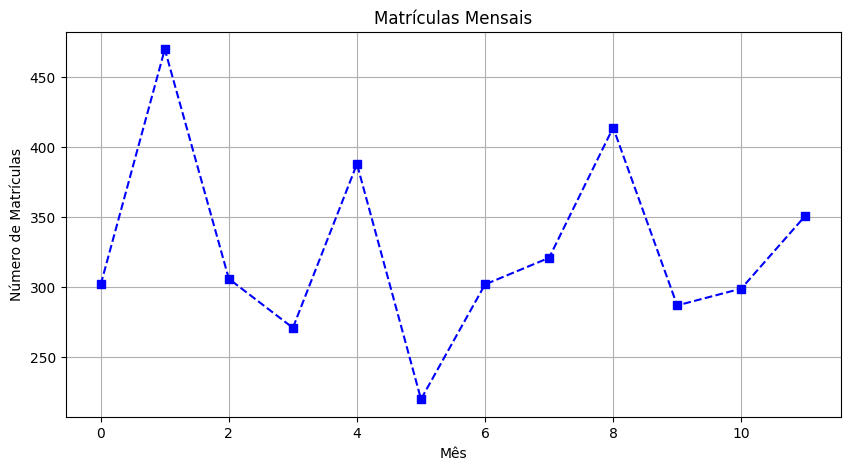

In [12]:
# Verificar o número de matriculas mensais
# 1- tamanho do gráfico ( figsize )
plt.figure(figsize=(10, 5))
df["Matrículas"].plot(marker='s', linestyle='--', color='blue')
plt.title("Matrículas Mensais") # Define o título do site
plt.xlabel('Mês') # Define o valor do eixo X do gráfico
plt.ylabel('Número de Matrículas') # Define o valor Y do gráfico
plt.grid(True) # Define que tera um GRID

In [13]:
# Identificar os meses com menor e maior numero de matriculas

max_matriculas = df['Matrículas'].max()
mes_max_matriculas = df['Matrículas'].idxmax()
print(f"Mês com maior número de matrículas: {mes_max_matriculas}: {max_matriculas} matrículas")

# ----------------------------------------------------------------------------------

min_matriculas = df['Matrículas'].min()
mes_min_matriculas = df['Matrículas'].idxmin()
print(f"Mês com menor número de matrículas: {mes_min_matriculas}: {min_matriculas} matrículas")

Mês com maior número de matrículas: 1: 470 matrículas
Mês com menor número de matrículas: 5: 220 matrículas


In [ ]:
media_matricula = df["Matrículas"].mean().round(2)

df["Mês_Formatado"] = df.index.to_series().dt.strftime("%d/%m/%Y")

print(df["Mês_Formatado"])

AttributeError: 'DataFrame' object has no attribute 'dt'

In [ ]:
print(df)

            Matrículas Mês_Formatado
Mês                                 
2022-01-31         302    31/01/2022
2022-02-28         470    28/02/2022
2022-03-31         306    31/03/2022
2022-04-30         271    30/04/2022
2022-05-31         388    31/05/2022
2022-06-30         220    30/06/2022
2022-07-31         302    31/07/2022
2022-08-31         321    31/08/2022
2022-09-30         414    30/09/2022
2022-10-31         287    31/10/2022
2022-11-30         299    30/11/2022
2022-12-31         351    31/12/2022


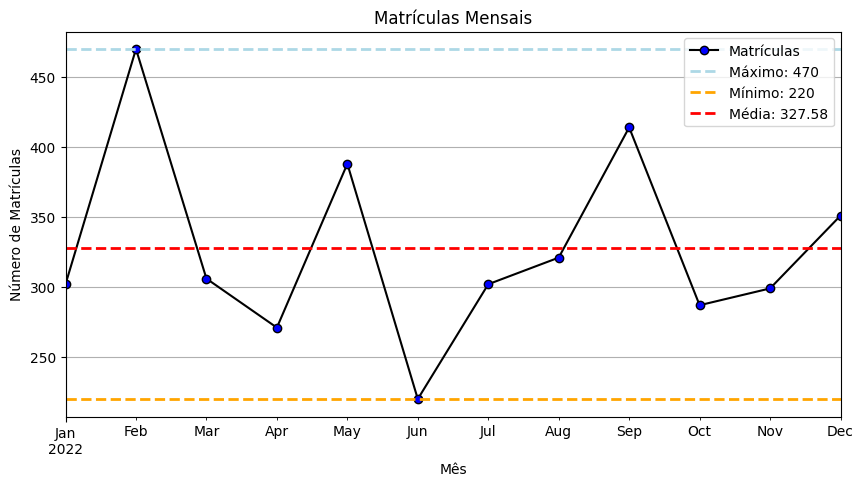

In [ ]:
# Plotar o gráfico geral 
plt.figure(figsize=(10,5))
df['Matrículas'].plot(marker='o', linestyle='-', 
                      color='black', label='Matrículas', mfc='blue', markersize= 6)

# Adicionar linha de info para maximo e minimo de matricula
plt.axhline(y=max_matriculas, color='lightblue', linestyle='--', linewidth=2, label=f'Máximo: {max_matriculas}')
plt.axhline(y=min_matriculas, color='orange', linestyle='--', linewidth=2, label=f'Mínimo: {min_matriculas}')
plt.axhline(y=media_matricula, color='red',linestyle="--", linewidth=2, label=f"Média: {media_matricula}")
plt.legend()
plt.title('Matrículas Mensais')
plt.xlabel('Mês')
plt.ylabel("Número de Matrículas")
plt.grid(True)

## Tendência de Matrículas

### calcular a media de matriculas por trimestre

##### QE - Trimestre
##### QS - Semestre
##### Q - Quadrimestre
##### A - Anual
##### D - Diário
##### W - Semanal
##### H - Horário

In [ ]:
df = df.reset_index() # Caso 'Mês' já seja índice, ele volta a ser coluna

df["Mês"] = pd.to_datetime(df["Mês"])

df.set_index("Mês", inplace=True)


# Passo 3 - Calcular a média como trimestral
matriculas_trimestre = df["Matrículas"].resample("QE").mean()

print(matriculas_trimestre)

Mês
2022-03-31    359.333333
2022-06-30    293.000000
2022-09-30    345.666667
2022-12-31    312.333333
Freq: QE-DEC, Name: Matrículas, dtype: float64


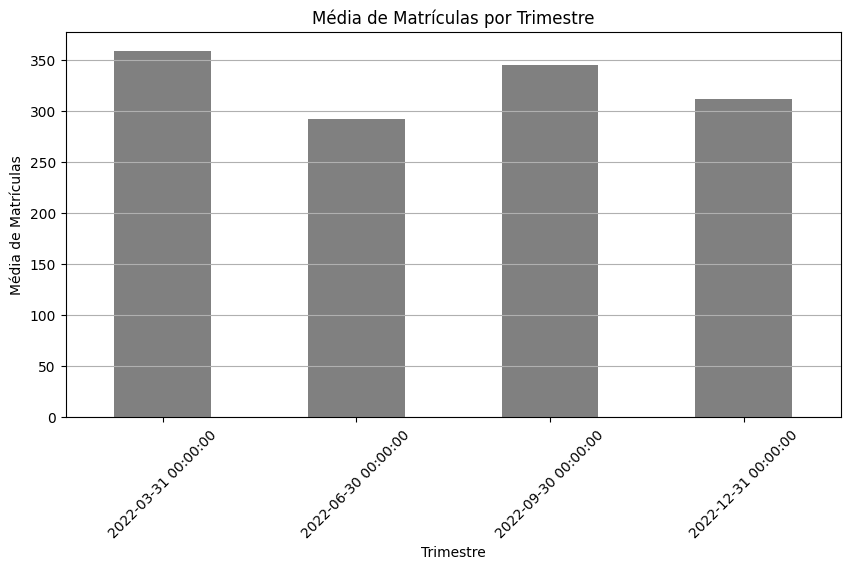

In [ ]:
# Plotar gráfico de barras
plt.figure(figsize=(10,5))
matriculas_trimestre.plot(kind='bar', color='gray')
plt.title("Média de Matrículas por Trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Média de Matrículas")
plt.xticks(rotation=45)
plt.grid(axis='y')

In [ ]:
print("Média de matriculas dos trimestres")

print(matriculas_trimestre.round(2))

Média de matriculas dos trimestres
Mês
2022-03-31    359.33
2022-06-30    293.00
2022-09-30    345.67
2022-12-31    312.33
Freq: QE-DEC, Name: Matrículas, dtype: float64


In [ ]:
df["Matrículas"].std() # Desvio padrão
df["Matrículas"] - df["Matrículas"].mean() #desvio simples

Mês
2022-01-31    -25.583333
2022-02-28    142.416667
2022-03-31    -21.583333
2022-04-30    -56.583333
2022-05-31     60.416667
2022-06-30   -107.583333
2022-07-31    -25.583333
2022-08-31     -6.583333
2022-09-30     86.416667
2022-10-31    -40.583333
2022-11-30    -28.583333
2022-12-31     23.416667
Name: Matrículas, dtype: float64

In [ ]:
variancia_percentual = df["Matrículas"].pct_change() *100

print(variancia_percentual)

Mês
2022-01-31          NaN
2022-02-28    55.629139
2022-03-31   -34.893617
2022-04-30   -11.437908
2022-05-31    43.173432
2022-06-30   -43.298969
2022-07-31    37.272727
2022-08-31     6.291391
2022-09-30    28.971963
2022-10-31   -30.676329
2022-11-30     4.181185
2022-12-31    17.391304
Name: Matrículas, dtype: float64


In [ ]:
tabela_variacao = pd.DataFrame({
    "Matrículas": df["Matrículas"],
    "Variação Percentual (%)": variancia_percentual
})
print(tabela_variacao)

            Matrículas  Variação Percentual (%)
Mês                                            
2022-01-31         302                      NaN
2022-02-28         470                55.629139
2022-03-31         306               -34.893617
2022-04-30         271               -11.437908
2022-05-31         388                43.173432
2022-06-30         220               -43.298969
2022-07-31         302                37.272727
2022-08-31         321                 6.291391
2022-09-30         414                28.971963
2022-10-31         287               -30.676329
2022-11-30         299                 4.181185
2022-12-31         351                17.391304


In [ ]:
print(variancia_percentual.round(2))

variancia_percentual.plot(marker='o', title='Variação Percentual nas Matrículas (%)')
plt.ylabel('Variação (%)')
plt.xlabel('Periodo')
plt.grid(True)
plt.show()

NameError: name 'variancia_percentual' is not defined

In [ ]:
import seaborn as sns

tabela_variacao = pd.DataFrame({
